# Simple models

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

In [15]:
# 1. Load and clean
loan_train = pd.read_csv('./Data/train.csv')

clean_age = loan_train.loc[loan_train['person_age'] <= 100, 'person_age'].median()
clean_emp = loan_train.loc[loan_train['person_emp_length'] <= 60, 'person_emp_length'].median()
loan_train.loc[loan_train['person_age'] > 100, 'person_age'] = clean_age
loan_train.loc[loan_train['person_emp_length'] > 60, 'person_emp_length'] = clean_emp

In [23]:
# Test Data
loan_test = pd.read_csv('./Data/test.csv')

clean_age = loan_test.loc[loan_test['person_age'] <= 100, 'person_age'].median()
clean_emp = loan_test.loc[loan_test['person_emp_length'] <= 60, 'person_emp_length'].median()
loan_test.loc[loan_test['person_age'] > 100, 'person_age'] = clean_age
loan_test.loc[loan_test['person_emp_length'] > 60, 'person_emp_length'] = clean_emp

In [ ]:
# 2. Split features/target and one-hot encode
X = loan_train.drop(columns=['id', 'loan_status'])
y = loan_train['loan_status']
X = pd.get_dummies(X, columns=[
    'person_home_ownership', 'loan_intent', 'loan_grade', 'cb_person_default_on_file'
], drop_first=True)

In [ ]:
# 2. Split features/target and one-hot encode - test
X = loan_test.drop(columns=['id', 'loan_status'])
y = loan_test['loan_status']
X = pd.get_dummies(X, columns=[
    'person_home_ownership', 'loan_intent', 'loan_grade', 'cb_person_default_on_file'
], drop_first=True)

In [17]:
# 3. Split into train/validation
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


In [18]:
print('Shared setup complete:', X_train.shape, X_val.shape)

Shared setup complete: (46916, 22) (11729, 22)


# Load the data

In [2]:
# Train Data
train_df = pd.read_csv('./Data/train.csv')

clean_age = train_df.loc[train_df['person_age'] <= 100, 'person_age'].median()
clean_emp = train_df.loc[train_df['person_emp_length'] <= 60, 'person_emp_length'].median()
train_df.loc[train_df['person_age'] > 100, 'person_age'] = clean_age
train_df.loc[train_df['person_emp_length'] > 60, 'person_emp_length'] = clean_emp

X = train_df.drop(columns=['id', 'loan_status'])
y = train_df['loan_status']

X = pd.get_dummies(X, columns=[
    'person_home_ownership', 'loan_intent', 'loan_grade', 'cb_person_default_on_file'
], drop_first=True)

print('Training data ready:', X.shape)

Training data ready: (58645, 22)


In [3]:
test_df = pd.read_csv('./Data/test.csv')

test_df.loc[test_df['person_age'] > 100, 'person_age'] = clean_age
test_df.loc[test_df['person_emp_length'] > 60, 'person_emp_length'] = clean_emp

test_ids = test_df['id']
test_loan = test_df.drop(columns=['id'])

test_loan = pd.get_dummies(test_loan, columns=[
    'person_home_ownership', 'loan_intent', 'loan_grade', 'cb_person_default_on_file'
], drop_first=True)

test_loan = test_loan.reindex(columns=X.columns, fill_value=0)

print('Test data ready:', test_loan.shape)

Test data ready: (39098, 22)


In [4]:
def print_results(model_name, y_val, y_val_pred):
    acc = accuracy_score(y_val, y_val_pred)
    f1 = f1_score(y_val, y_val_pred)
    cm = confusion_matrix(y_val, y_val_pred)

    print(f"\n===== {model_name} =====")
    print(f"Accuracy: {acc:.4f}")
    print(f"F1 Score: {f1:.4f}")
    print("\nConfusion Matrix:")
    print("                 Predicted 0   Predicted 1")
    print(f"Actual 0         {cm[0][0]:<13} {cm[0][1]}")
    print(f"Actual 1         {cm[1][0]:<13} {cm[1][1]}")
    print("\nFull classification report:")
    print(classification_report(y_val, y_val_pred))
    return acc, f1

# LOGISTIC REGRESSION

In [5]:
def run_logistic_regression(X, y, X_test=None, show_chart=True):
    X_train, X_val, y_train, y_val = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_val_scaled = scaler.transform(X_val)

    model = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
    model.fit(X_train_scaled, y_train)

    y_val_pred = model.predict(X_val_scaled)
    print_results("Logistic Regression", y_val, y_val_pred)

    if show_chart:
        cm = confusion_matrix(y_val, y_val_pred)
        plt.figure(figsize=(5, 4))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
        plt.title("Logistic Regression - Confusion Matrix")
        plt.xlabel("Predicted")
        plt.ylabel("Actual")
        plt.show()

    test_predictions = None
    if X_test is not None:
        X_test_scaled = scaler.transform(X_test)
        test_predictions = model.predict(X_test_scaled)
        print(f"\nPredicted default rate on test_loan: {test_predictions.mean() * 100:.2f}%")

    return model, test_predictions


===== Logistic Regression =====
Accuracy: 0.8450
F1 Score: 0.6051

Confusion Matrix:
                 Predicted 0   Predicted 1
Actual 0         8518          1541
Actual 1         277           1393

Full classification report:
              precision    recall  f1-score   support

           0       0.97      0.85      0.90     10059
           1       0.47      0.83      0.61      1670

    accuracy                           0.84     11729
   macro avg       0.72      0.84      0.75     11729
weighted avg       0.90      0.84      0.86     11729



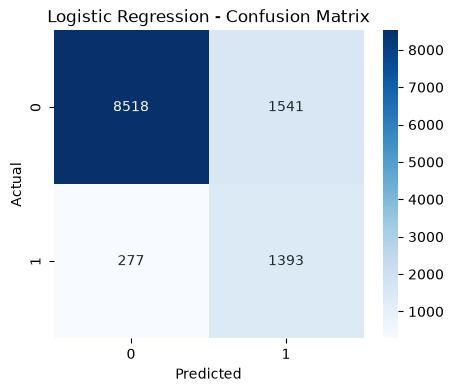


Predicted default rate on test_loan: 24.73%


In [8]:
lr_model, lr_test_preds = run_logistic_regression(X, y, X_test=test_loan)

# Random Forrest

In [6]:
def run_random_forest(X, y, X_test=None, show_chart=True):
    X_train, X_val, y_train, y_val = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    model = RandomForestClassifier(class_weight='balanced', n_estimators=300, random_state=42)
    model.fit(X_train, y_train)

    y_val_pred = model.predict(X_val)
    print_results("Random Forest", y_val, y_val_pred)

    if show_chart:
        cm = confusion_matrix(y_val, y_val_pred)
        fig, axes = plt.subplots(1, 2, figsize=(12, 4))

        sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', ax=axes[0])
        axes[0].set_title("Random Forest - Confusion Matrix")
        axes[0].set_xlabel("Predicted")
        axes[0].set_ylabel("Actual")

        importances = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False).head(10)
        importances.plot(kind='barh', ax=axes[1])
        axes[1].set_title("Top 10 Feature Importances")
        axes[1].invert_yaxis()

        plt.tight_layout()
        plt.show()

    test_predictions = None
    if X_test is not None:
        test_predictions = model.predict(X_test)
        print(f"\nPredicted default rate on test_loan: {test_predictions.mean() * 100:.2f}%")

    return model, test_predictions


===== Random Forest =====
Accuracy: 0.9447
F1 Score: 0.7917

Confusion Matrix:
                 Predicted 0   Predicted 1
Actual 0         9847          212
Actual 1         437           1233

Full classification report:
              precision    recall  f1-score   support

           0       0.96      0.98      0.97     10059
           1       0.85      0.74      0.79      1670

    accuracy                           0.94     11729
   macro avg       0.91      0.86      0.88     11729
weighted avg       0.94      0.94      0.94     11729



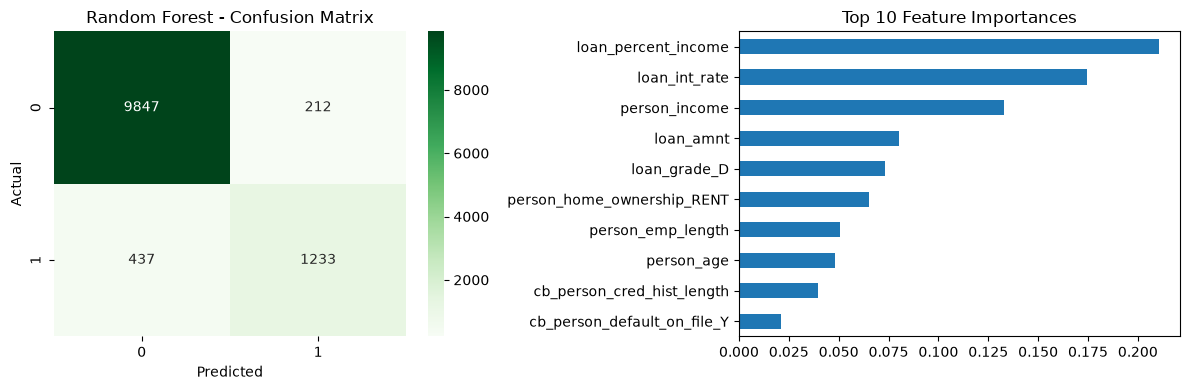


Predicted default rate on test_loan: 11.90%


In [9]:
rf_model, rf_test_preds = run_random_forest(X, y, X_test=test_loan)

# XGBOOST

In [7]:
def run_xgboost(X, y, X_test=None, show_chart=True):
    X_train, X_val, y_train, y_val = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
    model = XGBClassifier(
        n_estimators=300, max_depth=5, learning_rate=0.1,
        scale_pos_weight=scale_pos_weight, eval_metric='logloss', random_state=42
    )
    model.fit(X_train, y_train)

    y_val_pred = model.predict(X_val)
    print_results("XGBoost", y_val, y_val_pred)

    if show_chart:
        cm = confusion_matrix(y_val, y_val_pred)
        fig, axes = plt.subplots(1, 2, figsize=(12, 4))

        sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges', ax=axes[0])
        axes[0].set_title("XGBoost - Confusion Matrix")
        axes[0].set_xlabel("Predicted")
        axes[0].set_ylabel("Actual")

        importances = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False).head(10)
        importances.plot(kind='barh', ax=axes[1])
        axes[1].set_title("Top 10 Feature Importances")
        axes[1].invert_yaxis()

        plt.tight_layout()
        plt.show()

    test_predictions = None
    if X_test is not None:
        test_predictions = model.predict(X_test)
        print(f"\nPredicted default rate on test_loan: {test_predictions.mean() * 100:.2f}%")

    return model, test_predictions


===== XGBoost =====
Accuracy: 0.9270
F1 Score: 0.7660

Confusion Matrix:
                 Predicted 0   Predicted 1
Actual 0         9472          587
Actual 1         269           1401

Full classification report:
              precision    recall  f1-score   support

           0       0.97      0.94      0.96     10059
           1       0.70      0.84      0.77      1670

    accuracy                           0.93     11729
   macro avg       0.84      0.89      0.86     11729
weighted avg       0.93      0.93      0.93     11729



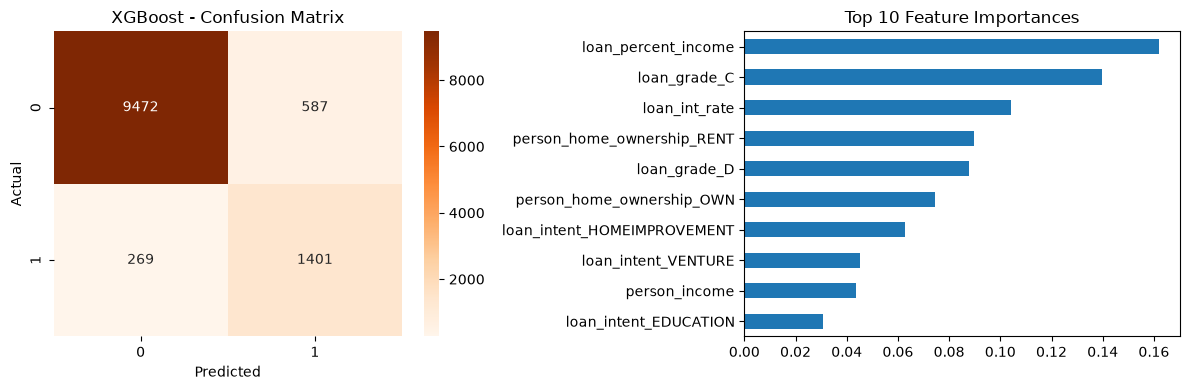


Predicted default rate on test_loan: 16.23%


In [10]:
xgb_model, xgb_test_preds = run_xgboost(X, y, X_test=test_loan)